In [14]:
%pip install pandas pydantic langgraph pydantic-ai nest_asyncio --quiet

Note: you may need to restart the kernel to use updated packages.


In [15]:
from pydantic import BaseModel
from typing import List, Optional, Literal, Dict, Any

# --- Semantic Layer Models ---

class ColumnStats(BaseModel):
    mean: Optional[float] = None
    median: Optional[float] = None
    std: Optional[float] = None
    min: Optional[float] = None
    max: Optional[float] = None
    unique_count: int

class ColumnSemantics(BaseModel):
    name: str
    dtype: Literal["int", "float", "string", "datetime", "category"]
    description: str
    unit: Optional[str] = None
    role: Literal["feature", "target", "id", "time", "category"]
    stats: Optional[ColumnStats] = None

class DatasetSemantics(BaseModel):
    dataset_name: str
    row_count: int
    columns: List[ColumnSemantics]
    primary_keys: List[str]
    time_column: Optional[str]
    missing_values: Dict[str, int]

# --- Analysis Layer Models ---

class AnalyticalQuestion(BaseModel):
    question: str
    category: str  # Trend, Segmentation, Correlation, Distribution, Performance, DataQuality, Behavioral
    priority: bool = False
    priority_reason: Optional[str] = None

class AnalyticalQuestionsOutput(BaseModel):
    dataset_understanding: str
    questions: List[AnalyticalQuestion]

# --- SQL Agent Models ---

class QueryResult(BaseModel):
    question: str                  # The question being answered
    query: str                     # The pandas query / code used
    result_summary: str            # LLM-written placeholder; always overwritten after execution
    explanation: str               # Why this result matters in business terms
    error: Optional[str] = None    # Populated if execution failed
    actual_result: Optional[str] = None  # Ground-truth: real executed output (never hallucinated)

class SQLAgentOutput(BaseModel):
    answers: List[QueryResult]

# --- Business Insights Agent Models ---

class ActionItem(BaseModel):
    title: str                        # Short action title, e.g. "Reduce failed transactions at Branch X"
    priority: Literal["High", "Medium", "Low"]
    what: str                         # What is happening (plain English, no jargon)
    why_it_matters: str               # Why the business owner should care
    recommendation: str               # Concrete action they can take
    expected_impact: str              # What improvement they can expect if they act

class BusinessInsightsOutput(BaseModel):
    executive_summary: str            # 2-3 sentence plain-English summary of the whole dataset
    action_items: List[ActionItem]    # Prioritised list of actions
    watch_out_for: List[str]          # Short list of risks or warning signs to monitor

# --- Manager Agent Models ---

class ManagerDecision(BaseModel):
    next_agent: Literal["question_agent", "sql_agent", "insights_agent", "refinement_agent", "done"]
    reasoning: str                 # Why the manager chose this next step
# --- Refinement Agent Models ---

class RefinementDecision(BaseModel):
    needs_refinement: bool
    target_agent: Optional[Literal["question_agent", "sql_agent", "insights_agent"]] = None
    failed_questions: Optional[List[str]] = None  # Exact question strings that need to be retried (sql_agent only)
    feedback: str                                 # Specific instruction for the target agent, or approval note
    reasoning: str                                # One-line summary of the decision

In [16]:
import pandas as pd
import numpy as np

def profile_dataframe(df: pd.DataFrame):
    profile = {}

    profile["columns"] = {}
    for col in df.columns:
        series = df[col]
        dtype = str(series.dtype)

        if np.issubdtype(series.dtype, np.number):
            stats = {
                "mean": float(series.mean()),
                "median": float(series.median()),
                "std": float(series.std()),
                "min": float(series.min()),
                "max": float(series.max()),
                "unique_count": int(series.nunique())
            }
        else:
            stats = {"unique_count": int(series.nunique())}

        profile["columns"][col] = {"dtype": dtype, "stats": stats}

    profile["missing"] = df.isnull().sum().to_dict()
    profile["row_count"] = len(df)
    return profile


def build_semantic_input(df: pd.DataFrame) -> str:
    import json
    profile = profile_dataframe(df)
    return json.dumps({"dataset_name": "uploaded_dataset", "profile": profile})


def validate_semantics(semantics: DatasetSemantics, df: pd.DataFrame) -> DatasetSemantics:
    """Validate the LLM-generated semantic model against the real dataframe.
    Raises ValueError for any hallucinated column names, keys, or time columns.
    """
    df_cols = set(df.columns)
    semantic_col_names = [c.name for c in semantics.columns]

    # 1. No hallucinated columns
    for col in semantics.columns:
        if col.name not in df_cols:
            raise ValueError(
                f"Hallucinated column in semantic model: '{col.name}' "
                f"(does not exist in dataframe). Real columns: {sorted(df_cols)}"
            )

    # 2. No missing columns
    for col in df_cols:
        if col not in semantic_col_names:
            raise ValueError(
                f"Column '{col}' exists in dataframe but is missing from semantic model."
            )

    # 3. Primary keys must exist
    for pk in semantics.primary_keys:
        if pk not in df_cols:
            raise ValueError(
                f"Invalid primary key: '{pk}' is not a real column."
            )

    # 4. Time column must exist if specified
    if semantics.time_column and semantics.time_column not in df_cols:
        raise ValueError(
            f"Invalid time_column: '{semantics.time_column}' is not a real column."
        )

    # 5. Row count must match actual data
    if semantics.row_count != len(df):
        # Correct silently rather than raising — LLM sometimes guesses this wrong
        semantics = semantics.model_copy(update={"row_count": len(df)})

    return semantics

In [17]:
from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIChatModel
from kaggle_secrets import UserSecretsClient
import nest_asyncio
import os

nest_asyncio.apply()

client = UserSecretsClient()
os.environ["OPENAI_API_KEY"] = client.get_secret("OPENAI_API_KEY")

model = OpenAIChatModel(model_name="gpt-4o")

# --- Semantic Agent ---
semantic_agent = Agent(
    model=model,
    output_type=DatasetSemantics,
    system_prompt="""
You are a strict semantic layer generator.

Rules:
- Only use provided profiling data
- Do NOT create new columns
- Do NOT generate insights or explanations
- Assign roles: id, time, feature, category
- If unsure, default to 'feature'
"""
)

# --- Question Agent ---
question_agent = Agent(
    model=model,
    output_type=AnalyticalQuestionsOutput,
    system_prompt="""
You are a senior data analyst and analytical strategist.
Your sole responsibility is to generate high-quality analytical questions that will be executed by a downstream SQL agent.
You do NOT analyze results.
You do NOT provide insights.
You do NOT generate SQL queries.
Your only job is to define the most valuable questions that can be answered using the dataset.

---

INPUT:
You will receive a semantic model of a dataset containing:
- Dataset name
- Row count
- Columns (name, type, role, description, statistics)
- Primary keys
- Time column (if present)
- Missing values

---

OBJECTIVES:

1. **Understand the dataset deeply**
   - Infer the meaning of each column
   - Understand relationships between variables
   - Identify roles (feature, target, id, time, category)
   - If a target column exists, treat it as the north star — the majority of questions should relate back to what drives, predicts, or correlates with it

2. **Think like a senior business analyst**
   - Focus on business value and decision-making
   - Identify what stakeholders would care about
   - Prioritize high-impact questions
   - Consider dataset size when prioritizing — avoid granular per-row questions on large datasets

3. **Generate comprehensive analytical questions**
You must generate 4-8 questions per category across these dimensions:
   - Trends & time-based analysis (only if time column exists)
   - Segmentation & group comparisons
   - Relationships & correlations
   - Distributions & outliers
   - Performance & ranking (top/bottom analysis)
   - Data quality & missing values (only for target, id, or time columns)
   - Behavioral or usage patterns

Aim for a MINIMUM of 15 questions total. More is better as long as they are not redundant.

4. **Question quality rules**
Each question must:
   - Start with: What, Which, How many, How does, or Is there
   - Be specific and unambiguous
   - Be measurable
   - Reference actual columns in the dataset
   - Be non-trivial
   - Lead to actionable insights
   - Be phrased in a way that directly maps to a SQL query

5. **Coverage requirement**
   - Cover all important columns
   - Explore relationships between multiple variables
   - Avoid redundancy
   - Provide a diverse set of questions

OUTPUT FORMAT:
Return a structured output with:
- dataset_understanding: brief description of the dataset, key variables, and target column if any
- questions: list of analytical questions, each with:
  - question: must start with What/Which/How many/How does/Is there
  - category: one of Trend, Segmentation, Correlation, Distribution, Performance, DataQuality, Behavioral
  - priority: true if this is one of the 5-10 most impactful questions
  - priority_reason: one sentence explaining why (only for priority=true)

CONSTRAINTS:
- Do NOT generate SQL queries
- Do NOT answer the questions
- Do NOT hallucinate columns not in the semantic model
- Every question must be answerable with SQL using the given schema
"""
)

# --- SQL Agent ---
sql_agent = Agent(
    model=model,
    output_type=SQLAgentOutput,
    system_prompt="""
You are an expert data analyst who answers analytical questions by writing pandas queries.

You will receive:
- A list of analytical questions
- The dataset schema (column names, types, roles)
- A sample of the dataframe (first 5 rows)

For EACH question you must produce:
1. query: a valid pandas code snippet using a variable called `df`. Keep it concise — one or two chained operations.
   Examples:
     df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(10)
     df[df['churn'] == 1]['age'].describe()
     df.corr()['target_col'].drop('target_col').abs().sort_values(ascending=False)

2. result_summary: Write EXACTLY this placeholder text — do NOT predict or invent any numbers or values:
   "PENDING: result will be computed by executing the query above."
   ⚠ CRITICAL ANTI-HALLUCINATION RULE: You have NOT seen the actual data output. Any specific numbers,
   rankings, or values you write here would be fabricated. The real result will replace this field
   automatically after execution. Writing fake numbers here causes wrong business decisions.

3. explanation: one or two sentences on why this result is business-relevant and what action it might suggest.
   Do NOT include specific numbers — those will come from the actual result.

RULES:
- Only use columns that exist in the provided schema
- Do NOT import any libraries — pandas is already available as `df`
- Do NOT use SQL syntax — only pandas
- If a question cannot be answered with the given schema, set error to a short explanation and leave query/result_summary/explanation empty
- For correlations: df[['col_a','col_b']].dropna().corr()
- For date parsing inline: pd.to_datetime(df['col'], format='%d/%m/%Y %H:%M', errors='coerce').dt.dayofweek
"""
)

# --- Business Insights Agent ---
insights_agent = Agent(
    model=model,
    output_type=BusinessInsightsOutput,
    system_prompt="""
You are a trusted business advisor translating data analysis results into clear, actionable guidance for a business owner with no data or technical background.

You will receive:
- A dataset understanding summary
- A list of analytical questions, each with an "actual_result" field and an "explanation" field

⚠ CRITICAL ANTI-HALLUCINATION RULES — READ CAREFULLY:
1. Every number, ranking, or value you write MUST come from the "actual_result" field of the corresponding Q&A pair.
2. NEVER invent, estimate, or extrapolate numbers not present in actual_result.
3. If actual_result is null or unavailable (query failed), DO NOT guess — omit the number or say "data unavailable".
4. The "explanation" field is LLM-generated context — it may contain wrong numbers. IGNORE any numbers in explanation; use only actual_result.
5. Before writing any number in your report, ask yourself: "Is this exact value present in the actual_result field?" If no → do not write it.

Your job is to read EVERY answered question and turn ALL meaningful findings into a thorough, honest, and actionable business report. Do not skip findings. Do not summarize vaguely.

---

OUTPUT STRUCTURE:

1. executive_summary
Write 4-6 sentences covering the overall picture of the business.
- Lead with the single most important finding (e.g. failure rates, revenue gaps, top performers)
- Include 3-4 specific numbers from the data
- Mention which locations/segments are strongest and weakest
- End with the single most urgent thing the owner should do
Example: "Your business processed 1,752 transactions totalling $14,651 across 3 malls last month. C Mall leads with $5,004 in revenue, while Y Mall trails at $4,715. However, Y Mall's Tla'a Al-Ali branch has the highest failure rate at 10.3% — nearly double the average — meaning roughly $500 in transactions are failing there every month. Your overall failure rate is 6.6% (115 out of 1,752 transactions), which is manageable but concentrated in specific branches. Start by investigating Tla'a Al-Ali this week."

2. action_items
You MUST read and consider every single answered question before writing anything.
For each answer, decide: is this finding actionable, surprising, or important to the owner?
If yes — write an action item for it.
If multiple questions point to the same issue (e.g. two questions both about failure rates), you may combine them into one richer action item.
Never silently skip a finding. If a result is not actionable on its own, fold it into the executive summary or a watch_out_for item instead.

For each action item:
- title: short and specific (name the branch/mall/metric)
- priority: High (revenue impact > $500/month or failure-related), Medium (performance gaps), Low (monitoring/optimization)
- what: 2-3 sentences using the EXACT numbers from the actual result. Do not invent numbers. Do not round dramatically. If the result says $5,004.38 say "just over $5,000".
- why_it_matters: the real business consequence if nothing changes. Include a number.
- recommendation: one concrete step. Name who should do it, when, and what success looks like.
- expected_impact: a specific number or range. Be honest — if you cannot estimate, say "difficult to estimate without more data" rather than inventing a number.

Rules:
- EVERY "what" field must use numbers directly from the actual data result
- Never use numbers from the result_summary if they differ from the actual result — always trust the actual result
- Be specific: "Y Mall Tla'a Al-Ali" not "one of your branches"
- No jargon: no "correlation", "distribution", "normalize", "dtype"
- Never say "consider" or "may want to"

3. watch_out_for
List 5-7 specific warning signs based on the actual data.
Each must name a specific metric, threshold, and consequence.
Example: "If Y Mall Tla'a Al-Ali's failure rate stays above 10% next month, escalate to the branch manager — it's already costing you roughly $500/month in lost transactions."

---

TONE:
- Direct, warm, and confident — like a trusted advisor who has read every number
- Never vague. Every sentence should contain a fact or an action.
- Use plain language. If you need a technical term, explain it in the same sentence.
- Focus entirely on what the owner can do with this information.
"""
)

# --- Refinement Agent ---
refinement_agent = Agent(
    model=model,
    output_type=RefinementDecision,
    system_prompt="""
You are the team lead of a data analysis pipeline.
Your job is to review the full output of the team — the questions generated, the SQL answers, and the business insights — and decide if the work is good enough or needs improvement.

You will receive:
- The analytical questions that were generated
- The SQL answers (including actual data results)
- The business insights report produced for the business owner

---

WHAT TO CHECK:

1. Questions quality
- Are the questions specific and tied to actual columns?
- Are there important angles that were completely missed (e.g. no time-based questions when a date column exists)?
- Are there too many redundant questions covering the same thing?

2. SQL answers quality
- Did any questions fail to execute (error field is set)?
- Does the actual_result field contain real data (not empty / all-NaN)?
- Are there answers where the query logic looks wrong for the question asked?
- ⚠ Do NOT flag answers just because result_summary is vague — the ground truth is always in actual_result.

3. Business insights quality
- Does every action item include real numbers from the data's actual_result fields?
- ⚠ Cross-check: for each number cited in the insights, verify it appears in the corresponding actual_result. Flag any number that cannot be traced to an actual_result.
- Are the recommendations specific and actionable, or vague?
- Does the executive summary actually reflect what the data showed?
- Are there important findings from the SQL answers that were completely ignored in the insights?

---

DECISION RULES:

- If everything is good enough: set needs_refinement=false, leave target_agent and feedback null
- If something needs fixing: set needs_refinement=true, pick ONE target_agent, and write specific feedback

When writing feedback:
- Be specific about what is wrong and what the agent should do differently
- Reference exact column names and the exact question text from the output
- Do NOT give vague feedback like "improve quality" — say exactly what to fix and how

For sql_agent failures specifically:
- Populate failed_questions with the EXACT question strings (copy them verbatim) that need to be retried
- In feedback, explain for EACH failed question exactly what went wrong and what the correct pandas approach should be
- Example feedback: "Question 'How does tax_amount correlate with transaction_amount?' returned nan because corr() needs both columns to be numeric and non-null. Retry with: df[['tax_amount','transaction_amount']].dropna().corr()"
- Only include questions that genuinely failed — do NOT re-run questions that produced valid results

Priority order if multiple issues exist:
1. Fix SQL errors/bad results first (broken answers make insights unreliable)
2. Fix missing critical questions second
3. Fix weak insights third

---

IMPORTANT:
- Be honest but not a perfectionist — if the output is good enough, approve it
- Only request refinement if the improvement would meaningfully change what the business owner understands or does
- You can only request a re-run of each agent once — if an agent has already been re-run, approve its output
"""
)

# --- Manager Agent ---
manager_agent = Agent(
    model=model,
    output_type=ManagerDecision,
    system_prompt="""
You are the manager of a data analysis pipeline.
You coordinate two specialist agents: the question agent and the SQL agent.

Your job is to decide what happens next at each step of the pipeline.

You will receive the current state of the pipeline:
- Whether questions have been generated yet
- Whether answers have been generated yet

Your decision options:
- "question_agent": run the question agent to generate analytical questions (only if questions are not yet generated)
- "sql_agent": run the SQL agent to answer the questions (only if questions exist but answers do not)
- "insights_agent": run the business insights agent to produce plain-English recommendations (only if answers exist but insights do not)
- "refinement_agent": run the refinement agent to review all outputs and decide if anything needs to be redone (only after insights exist, and only if refinement has not run yet OR the previous refinement requested a re-run that has now completed)
- "done": the pipeline is complete (questions, answers, insights, and a refinement check all exist and no further refinement is needed)

Be decisive. Do not repeat steps that are already complete.
Return your decision as next_agent and a one-sentence reasoning.
"""
)

In [18]:
from typing import TypedDict, Optional, List, Dict
import pandas as pd

class MasterState(TypedDict):
    # Input
    df: pd.DataFrame

    # Semantic subgraph output
    semantic_model: DatasetSemantics

    # Analysis subgraph outputs
    questions: Optional[AnalyticalQuestionsOutput]
    answers: Optional[List[QueryResult]]
    insights: Optional[BusinessInsightsOutput]

    # Refinement
    refinement: Optional[RefinementDecision]
    refinement_feedback: Optional[str]
    refinement_failed_questions: Optional[List[str]]  # specific questions to retry
    refinement_count: int
    rerun_history: Dict[str, bool]   # which agents have already been re-run

    # Manager log and internal routing signal
    manager_log: List[str]
    _next: str

In [19]:
from langgraph.graph import StateGraph

# --- Node ---
async def semantic_node(state: MasterState):
    df = state["df"]
    semantic_input = build_semantic_input(df)
    result = await _agent_run_with_retry(semantic_agent, semantic_input, "semantic_agent")
    validated = validate_semantics(result.output, df)
    return {"semantic_model": validated}

# --- Subgraph ---
semantic_builder = StateGraph(MasterState)
semantic_builder.add_node("semantic_layer", semantic_node)
semantic_builder.set_entry_point("semantic_layer")
semantic_builder.set_finish_point("semantic_layer")
semantic_subgraph = semantic_builder.compile()

In [20]:
import json
import asyncio
from langgraph.graph import StateGraph
from typing import Literal

# ── Timeout + Retry wrapper ───────────────────────────────────────────────────
AGENT_TIMEOUT = 120  # seconds per agent call
AGENT_MAX_RETRIES = 3

async def _agent_run_with_retry(agent, prompt: str, label: str = "agent"):
    """Run an agent call with timeout and exponential backoff retry."""
    for attempt in range(1, AGENT_MAX_RETRIES + 1):
        try:
            result = await asyncio.wait_for(
                agent.run(prompt),
                timeout=AGENT_TIMEOUT
            )
            return result
        except asyncio.TimeoutError:
            if attempt < AGENT_MAX_RETRIES:
                wait = 5 * attempt
                print(f"  [{label}] Timed out (attempt {attempt}/{AGENT_MAX_RETRIES}), retrying in {wait}s...")
                await asyncio.sleep(wait)
            else:
                raise RuntimeError(f"[{label}] All {AGENT_MAX_RETRIES} attempts timed out after {AGENT_TIMEOUT}s each.")
        except Exception as e:
            if attempt < AGENT_MAX_RETRIES:
                wait = 5 * attempt
                print(f"  [{label}] Error: {e} (attempt {attempt}/{AGENT_MAX_RETRIES}), retrying in {wait}s...")
                await asyncio.sleep(wait)
            else:
                raise

# ── Question Node ─────────────────────────────────────────────────────────────
async def question_node(state):
    print("  [question_agent] Generating analytical questions...")
    semantic = state["semantic_model"]
    df       = state["df"]
    sample   = df.head(5).to_dict(orient="records")
    feedback = state.get("refinement_feedback")

    payload = {
        "semantic_model":   semantic.model_dump(),
        "dataframe_sample": sample
    }
    if feedback:
        payload["refinement_feedback"] = (
            f"REFINEMENT FEEDBACK — add to or improve the existing questions:\n{feedback}"
        )

    result = await _agent_run_with_retry(question_agent, json.dumps(payload), "question_agent")
    qs = result.output
    print(f"  [question_agent] Done — {len(qs.questions)} questions generated.")
    return {"questions": qs, "refinement_feedback": None}


# ── SQL helpers ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

def _is_bad_result(result) -> bool:
    """Returns True if the result is empty, all-NaN, or trivially useless."""
    try:
        if result is None:
            return True
        if isinstance(result, (int, float)):
            return np.isnan(result)
        if isinstance(result, pd.Series):
            return result.empty or result.isna().all()
        if isinstance(result, pd.DataFrame):
            return result.empty or result.isna().all().all()
        return False
    except Exception:
        return False


def _execute_query(query: str, df) -> tuple:
    """Execute a query. Returns (result, error_string)."""
    try:
        result = eval(query, {"df": df, "pd": pd, "np": np})
        if _is_bad_result(result):
            return None, f"Query returned empty/NaN result: {repr(result)}"
        return result, None
    except Exception as e:
        return None, f"Execution error: {str(e)}"


async def _run_batch(questions_batch, schema, sample, feedback_map, df):
    """Run one batch through the SQL agent, execute each query, return answers."""
    payload = {
        "questions":        questions_batch,
        "schema":           schema,
        "dataframe_sample": sample
    }
    if feedback_map:
        payload["retry_feedback"] = feedback_map

    result = await _agent_run_with_retry(sql_agent, json.dumps(payload), "sql_agent")

    executed = []
    for answer in result.output.answers:
        if answer.error:
            executed.append(answer)
            continue
        exec_result, err = _execute_query(answer.query, df)
        if err:
            answer.error = err
        else:
            # ── Anti-hallucination: replace LLM-predicted summary with ground truth ──
            actual_str = str(exec_result)
            answer.actual_result = actual_str          # store raw ground truth
            answer.result_summary = (                  # override — never use LLM's fabricated numbers
                f"Actual result (executed, not predicted):\n{actual_str}"
            )
        executed.append(answer)
    return executed


# ── SQL Node ──────────────────────────────────────────────────────────────────
MAX_RETRIES = 2
BATCH_SIZE  = 5

async def sql_node(state):
    questions        = state["questions"]
    semantic         = state["semantic_model"]
    df               = state["df"]
    sample           = df.head(5).to_dict(orient="records")
    refinement_fb    = state.get("refinement_feedback")
    failed_qs        = state.get("refinement_failed_questions") or []
    existing_answers = list(state.get("answers") or [])

    schema = [
        {"name": c.name, "dtype": c.dtype, "role": c.role, "description": c.description}
        for c in semantic.columns
    ]

    # On re-run from refinement: only retry the specific failed questions
    if failed_qs:
        questions_to_run = failed_qs
        print(f"  [sql_agent] Re-running {len(questions_to_run)} failed question(s) from refinement...")
    else:
        questions_to_run = [q.question for q in questions.questions]
        print(f"  [sql_agent] Answering {len(questions_to_run)} questions...")

    # Pass 1: run all questions
    all_answers = []
    for i in range(0, len(questions_to_run), BATCH_SIZE):
        batch = questions_to_run[i:i + BATCH_SIZE]
        print(f"  [sql_agent] Batch {i // BATCH_SIZE + 1} ({len(batch)} questions)...")
        fb_map = {q: refinement_fb for q in batch} if refinement_fb else {}
        answers = await _run_batch(batch, schema, sample, fb_map, df)
        all_answers.extend(answers)

    # Self-healing retry loop — fix bad answers internally before returning
    for retry in range(1, MAX_RETRIES + 1):
        bad = [a for a in all_answers if a.error]
        if not bad:
            break

        print(f"  [sql_agent] Self-healing retry {retry}/{MAX_RETRIES} — fixing {len(bad)} bad answer(s)...")

        feedback_map = {}
        for a in bad:
            feedback_map[a.question] = (
                f"Previous query was: {a.query!r}\n"
                f"It failed with: {a.error}\n"
                f"Fix it. Requirements:\n"
                f"- Must be a single eval()-able pandas expression, no assignments\n"
                f"- To parse dates inline use: pd.to_datetime(df['col'], errors='coerce').dt.to_period('M')\n"
                f"- For correlations: df[['col_a','col_b']].dropna().corr()\n"
                f"- Never use multi-line code or import statements"
            )

        retry_qs = [a.question for a in bad]
        retry_answers = []
        for i in range(0, len(retry_qs), BATCH_SIZE):
            batch = retry_qs[i:i + BATCH_SIZE]
            fb_map = {q: feedback_map[q] for q in batch}
            answers = await _run_batch(batch, schema, sample, fb_map, df)
            retry_answers.extend(answers)

        # Swap in the retried answers
        retry_map = {a.question: a for a in retry_answers}
        all_answers = [
            retry_map.get(a.question, a) if a.error else a
            for a in all_answers
        ]

    # Report
    good = [a for a in all_answers if not a.error]
    bad  = [a for a in all_answers if a.error]
    if bad:
        print(f"  [sql_agent] Done — {len(good)} good, {len(bad)} still failed after {MAX_RETRIES} retries:")
        for a in bad:
            print(f"    still failed: {a.question[:80]}")
    else:
        print(f"  [sql_agent] Done — all {len(good)} answers valid ✓")

    # Merge back with existing answers if this was a targeted refinement re-run
    if failed_qs and existing_answers:
        failed_set = set(failed_qs)
        kept = [a for a in existing_answers if a.question not in failed_set]
        final_answers = kept + all_answers
        print(f"  [sql_agent] Merged — kept {len(kept)}, replaced {len(all_answers)}.")
    else:
        final_answers = all_answers

    print(f"  [sql_agent] Total: {len(final_answers)} answers.")
    return {
        "answers":                     final_answers,
        "refinement_feedback":         None,
        "refinement_failed_questions": None
    }


# ── Insights Node ─────────────────────────────────────────────────────────────
def _trim_result(answer, max_chars: int = 400) -> str:
    """Return the ground-truth execution result. Uses actual_result field first (never hallucinated),
    falls back to extracting from result_summary for backwards compatibility."""
    # Prefer the dedicated actual_result field (set after real execution)
    raw = getattr(answer, "actual_result", None) or answer.result_summary or ""
    if not raw:
        return ""
    # Strip any prefix marker if present (backwards compat)
    for marker in ["Actual result (executed, not predicted):\n", "Actual result:\n"]:
        if raw.startswith(marker):
            raw = raw[len(marker):]
            break
    if len(raw) > max_chars:
        raw = raw[:max_chars] + "\n... (truncated)"
    return raw


async def insights_node(state):
    print("  [insights_agent] Generating business insights...")
    questions = state["questions"]
    answers   = state["answers"]
    feedback  = state.get("refinement_feedback")

    qa_pairs = [
        {
            "question":      a.question,
            # ── Anti-hallucination: only pass ground-truth execution output ──────
            # Never pass a.result_summary directly — it may contain LLM-fabricated numbers.
            # _trim_result() extracts only the real executed result.
            "actual_result": _trim_result(a) if not a.error else None,
            "explanation":   a.explanation,
            "error":         a.error
        }
        for a in answers
    ]

    payload = {
        "dataset_understanding": questions.dataset_understanding,
        "qa_pairs": qa_pairs
    }
    if feedback:
        payload["refinement_feedback"] = (
            f"REFINEMENT FEEDBACK — address these issues in your report:\n{feedback}"
        )

    prompt = json.dumps(payload)
    print(f"  [insights_agent] Prompt size: {len(prompt):,} chars across {len(qa_pairs)} Q&A pairs.")

    result = await _agent_run_with_retry(insights_agent, prompt, "insights_agent")
    print("  [insights_agent] Done.")
    return {"insights": result.output, "refinement_feedback": None}


# ── Refinement Node ───────────────────────────────────────────────────────────
async def refinement_node(state):
    print("  [refinement_agent] Reviewing all outputs...")
    questions = state["questions"]
    answers   = state["answers"]
    insights  = state["insights"]

    prompt = json.dumps({
        "questions": [
            {"question": q.question, "category": q.category, "priority": q.priority}
            for q in questions.questions
        ],
        "answers": [
            {
                "question":      a.question,
                "query":         a.query,
                # ── Anti-hallucination: pass actual_result, NOT result_summary ──
                # result_summary may contain LLM-predicted (hallucinated) numbers.
                # actual_result is always the real executed output.
                "actual_result": (a.actual_result or "")[:400] if not a.error else None,
                "explanation":   a.explanation,
                "error":         a.error
            }
            for a in answers
        ],
        "insights": {
            "executive_summary": insights.executive_summary,
            "action_items": [
                {
                    "title":           ai.title,
                    "priority":        ai.priority,
                    "what":            ai.what,
                    "why_it_matters":  ai.why_it_matters,
                    "recommendation":  ai.recommendation,
                    "expected_impact": ai.expected_impact
                }
                for ai in insights.action_items
            ],
            "watch_out_for": insights.watch_out_for
        }
    })

    result = await _agent_run_with_retry(refinement_agent, prompt, "refinement_agent")
    decision = result.output
    count = (state.get("refinement_count") or 0) + 1

    status = "✓ Approved" if not decision.needs_refinement else f"↺ Re-run {decision.target_agent}"
    print(f"  [refinement_agent] {status} — {decision.reasoning}")
    if decision.needs_refinement and decision.failed_questions:
        for fq in decision.failed_questions:
            print(f"    Failed: {fq}")

    return {
        "refinement":                  decision,
        "refinement_count":            count,
        "refinement_feedback":         decision.feedback if decision.needs_refinement else None,
        "refinement_failed_questions": decision.failed_questions if decision.needs_refinement else None
    }


# ── Manager Node ──────────────────────────────────────────────────────────────
async def manager_node(state):
    questions        = state.get("questions")
    answers          = state.get("answers")
    insights         = state.get("insights")
    refinement       = state.get("refinement")
    rerun_history    = dict(state.get("rerun_history") or {})

    log     = list(state.get("manager_log") or [])
    updates = {}

    if questions is None:
        next_agent = "question_agent"

    elif answers is None or len(answers) == 0:
        next_agent = "sql_agent"

    elif insights is None:
        next_agent = "insights_agent"

    elif refinement is None:
        next_agent = "refinement_agent"

    elif not refinement.needs_refinement:
        next_agent = "done"

    else:
        target = refinement.target_agent

        if rerun_history.get(target):
            # Already re-ran this agent once — accept and finish
            print(f"  [manager] {target} already had one re-run, accepting and finishing.")
            next_agent = "done"
        else:
            # Mark this agent as re-run so it can't loop again
            rerun_history[target] = True
            updates["rerun_history"] = rerun_history

            # Clear refinement — it will re-run after the targeted fix
            updates["refinement"] = None

            # IMPORTANT: only clear insights if insights_agent itself is the target
            # For sql_agent re-runs, insights stays — we only swap the fixed answers in
            # and let insights re-run after the merge to incorporate the fixes
            if target == "sql_agent":
                updates["insights"] = None   # rebuild insights with fixed answers
            elif target == "question_agent":
                updates["answers"]  = None
                updates["insights"] = None

            next_agent = target

    log.append(f"Manager → {next_agent}")
    print(f"  [manager] → {next_agent}")
    updates["manager_log"] = log
    updates["_next"] = next_agent
    return updates


# ── Router ────────────────────────────────────────────────────────────────────
def route_from_manager(state) -> Literal["question_agent", "sql_agent", "insights_agent", "refinement_agent", "done"]:
    return state.get("_next", "done")


# ── Analysis Subgraph ─────────────────────────────────────────────────────────
analysis_builder = StateGraph(MasterState)

analysis_builder.add_node("manager",          manager_node)
analysis_builder.add_node("question_agent",   question_node)
analysis_builder.add_node("sql_agent",        sql_node)
analysis_builder.add_node("insights_agent",   insights_node)
analysis_builder.add_node("refinement_agent", refinement_node)

analysis_builder.set_entry_point("manager")

analysis_builder.add_conditional_edges(
    "manager",
    route_from_manager,
    {
        "question_agent":   "question_agent",
        "sql_agent":        "sql_agent",
        "insights_agent":   "insights_agent",
        "refinement_agent": "refinement_agent",
        "done":             "__end__"
    }
)

analysis_builder.add_edge("question_agent",   "manager")
analysis_builder.add_edge("sql_agent",        "manager")
analysis_builder.add_edge("insights_agent",   "manager")
analysis_builder.add_edge("refinement_agent", "manager")

analysis_subgraph = analysis_builder.compile()

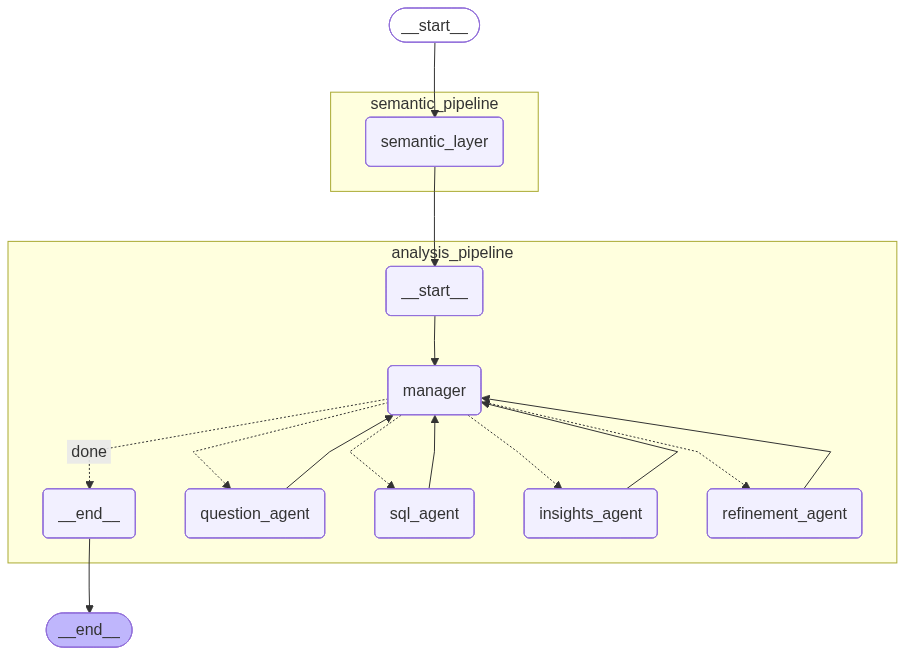

In [21]:
from langgraph.graph import StateGraph
from IPython.display import Image, display

# --- Master graph wires subgraphs together ---
master_builder = StateGraph(MasterState)

master_builder.add_node("semantic_pipeline", semantic_subgraph)
master_builder.add_node("analysis_pipeline", analysis_subgraph)

# Semantic output flows directly into analysis
master_builder.add_edge("semantic_pipeline", "analysis_pipeline")

master_builder.set_entry_point("semantic_pipeline")
master_builder.set_finish_point("analysis_pipeline")

master_graph = master_builder.compile()

display(Image(master_graph.get_graph(xray=True).draw_mermaid_png()))

In [22]:
df = pd.read_csv("/kaggle/input/datasets/omaralnajjarr/financial-data/jordan_transactions.csv")

In [23]:
from collections import defaultdict

result = await master_graph.ainvoke({"df": df})

semantic_model   = result["semantic_model"]
questions_output = result["questions"]
answers          = result["answers"]
insights         = result["insights"]
refinement       = result.get("refinement")
manager_log      = result.get("manager_log", [])

# ── Manager Log ───────────────────────────────────────────────────────────────
print("=== Manager Log ===")
for entry in manager_log:
    print(f"  {entry}")

# ── Semantic Model ────────────────────────────────────────────────────────────
print("\n=== Semantic Model ===")
for col in semantic_model.columns:
    print(f"  {col.name} | {col.dtype} | {col.role} | {col.description}")

# ── Analytical Questions ──────────────────────────────────────────────────────
print("\n=== Analytical Questions by Category ===")
by_category = defaultdict(list)
for q in questions_output.questions:
    by_category[q.category].append(q)

for category, qs in by_category.items():
    print(f"\n--- {category} ---")
    for q in qs:
        marker = "★" if q.priority else " "
        print(f"  {marker} {q.question}")

# ── SQL Answers ───────────────────────────────────────────────────────────────
print("\n=== SQL Answers ===")
for a in answers:
    print(f"\nQ: {a.question}")
    if a.error:
        print(f"  ERROR: {a.error}")
    else:
        print(f"  Query:       {a.query}")
        print(f"  Summary:     {a.result_summary}")
        print(f"  Explanation: {a.explanation}")

# ── Business Insights ─────────────────────────────────────────────────────────
# ── Refinement Review ─────────────────────────────────────────────────────────
if refinement:
    print("\n=== Refinement Review ===")
    status = "✓ Approved" if not refinement.needs_refinement else f"↺ Requested re-run of {refinement.target_agent}"
    print(f"  Status:    {status}")
    print(f"  Reasoning: {refinement.reasoning}")
    if refinement.needs_refinement and refinement.feedback:
        print(f"  Feedback:  {refinement.feedback}")

print("\n" + "="*60)
print("  BUSINESS INSIGHTS REPORT")
print("="*60)

print(f"\n{insights.executive_summary}")

print("\n--- Action Items ---")
for i, action in enumerate(insights.action_items, 1):
    print(f"\n[{action.priority}] {i}. {action.title}")
    print(f"  What's happening:  {action.what}")
    print(f"  Why it matters:    {action.why_it_matters}")
    print(f"  Recommendation:    {action.recommendation}")
    print(f"  Expected impact:   {action.expected_impact}")

print("\n--- Watch Out For ---")
for warning in insights.watch_out_for:
    print(f"  ⚠  {warning}")

  [manager] → question_agent
  [question_agent] Generating analytical questions...
  [question_agent] Done — 15 questions generated.
  [manager] → sql_agent
  [sql_agent] Answering 15 questions...
  [sql_agent] Batch 1 (5 questions)...
  [sql_agent] Batch 2 (5 questions)...
  [sql_agent] Batch 3 (5 questions)...
  [sql_agent] Self-healing retry 1/2 — fixing 2 bad answer(s)...


<string>:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.


  [sql_agent] Self-healing retry 2/2 — fixing 1 bad answer(s)...
  [sql_agent] Done — all 7 answers valid ✓
  [sql_agent] Total: 7 answers.
  [manager] → insights_agent
  [insights_agent] Generating business insights...
  [insights_agent] Prompt size: 3,707 chars across 7 Q&A pairs.
  [insights_agent] Done.
  [manager] → refinement_agent
  [refinement_agent] Reviewing all outputs...
  [refinement_agent] ↺ Re-run insights_agent — The insights report contains discrepancies between the numbers and claims made. For example, the claim that C Mall has the highest number of transactions is not substantiated by the results. Such inconsistencies could mislead business decisions. Therefore, the insights require refinement to accurately and fully integrate SQL findings into the business context.
  [manager] → insights_agent
  [insights_agent] Generating business insights...
  [insights_agent] Prompt size: 4,270 chars across 7 Q&A pairs.
  [insights_agent] Done.
  [manager] → refinement_agent
  [r

<string>:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
<string>:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.


  [sql_agent] Self-healing retry 2/2 — fixing 5 bad answer(s)...
  [sql_agent] Done — 7 good, 5 still failed after 2 retries:
    still failed: How many transactions occurred in each mall during weekends compared to weekdays
    still failed: How does transaction_amount vary across different seasons?
    still failed: What are the most common transaction types (e.g., Sale, Refund) across holidays 
    still failed: Is there a pattern in transaction_status over different months?
    still failed: What are the behavioral patterns in transactions during peak customer hours?
  [sql_agent] Total: 12 answers.
  [manager] → insights_agent
  [insights_agent] Generating business insights...
  [insights_agent] Prompt size: 5,704 chars across 12 Q&A pairs.
  [insights_agent] Done.
  [manager] → refinement_agent
  [refinement_agent] Reviewing all outputs...
  [refinement_agent] ↺ Re-run sql_agent — Several SQL queries failed to execute or produced invalid results due to syntax errors or missing da